# **Sales Analysis**

In [113]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [114]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [115]:
sales_df = pd.read_csv(
    'dataset/processed/ecommerce_processed.csv',
    parse_dates=['order_date']
)

In [116]:
sales_df.sample(10)

,order_date,order_year,order_month,order_day_of_week,part_day,is_weekend,customer_name,gender,age,age_group,customer_segment,country,order_status,category,sub_category,unit_price_usd,price_tier,quantity,quantity_segment,gross_revenue_usd,discount_amount_usd,discount_percent,discount_tier,is_discounted,net_revenue_usd,order_value_segment,profit_usd,profit_margin_percent,payment_method,shipping_method,shipping_cost_usd,shipping_cost_percent,delivery_days,delivery_speed,shipping_country,shipment_type,rating,customer_loyalty_score,loyalty_tier,coupon_used,session_duration_min,engagement_level,pages_visited,abandoned_cart_before,fraud_risk_score,fraud_risk_level,device_type,campaign_source,traffic_source
256531,2025-02-06 06:16:09.214268,2025,2,Thu,Morning,No,Gerald Lucas,Male,29,25-34,Regular,Australia,Completed,Home,Kitchen,84.65,Mid-Range,1,Single,84.65,8.46,10,Low Discount,Yes,76.19,Low,17.60,23.10,PayPal,Economy,3.28,4.31,10,Slow,Australia,Domestic,4,27.10,Low,No,22.80,Medium,16,No,73.10,High,Mobile,Affiliate,Search
894135,2024-10-20 08:58:05.384587,2024,10,Sun,Morning,Yes,Jacob Cohen,Male,64,55-64,Regular,Netherlands,Completed,Clothing,Kids Wear,72.01,Mid-Range,2,Small Basket,144.02,36.01,25,High Discount,Yes,108.01,Medium,11.33,10.49,PayPal,Standard,7.36,6.81,5,Standard,Netherlands,Domestic,5,79.90,High,No,49.60,High,2,No,88.20,High,Mobile,Instagram,Direct
940148,2025-11-21 11:19:02.802657,2025,11,Fri,Morning,No,Heather Santos,Female,22,18-24,Regular,United Kingdom,Completed,Electronics,Cameras,170.07,Premium,2,Small Basket,340.14,85.03,25,High Discount,Yes,255.11,Medium,118.89,46.60,PayPal,Express,8.01,3.14,6,Standard,United Kingdom,Domestic,5,5.60,Low,No,43.00,High,20,Yes,47.10,Medium,Mobile,Facebook,Search
225844,2025-01-29 06:12:52.067748,2025,1,Wed,Morning,No,Courtney Mckinney,Female,37,35-44,VIP,Belgium,Completed,Clothing,Kids Wear,76.33,Mid-Range,4,Bulk,305.32,0.00,0,No Discount,No,305.32,High,167.64,54.91,Apple Pay,Next Day,9.27,3.04,12,Slow,Belgium,Domestic,3,34.80,Medium,No,38.60,Medium,2,Yes,58.40,Medium,Tablet,Email,Direct
742078,2025-06-19 09:50:11.770176,2025,6,Thu,Morning,No,Kevin Briggs,Male,71,65+,Regular,Belgium,Completed,Health,Medical Devices,106.60,Premium,2,Small Basket,213.20,31.98,15,Medium Discount,Yes,181.22,Medium,54.18,29.90,Bank Transfer,Express,6.53,3.60,8,Slow,Belgium,Domestic,4,25.40,Low,Yes,43.40,High,11,No,67.70,Medium,Mobile,Email,Social
474848,2025-06-16 22:08:40.450464,2025,6,Mon,Evening,No,Gina Winters,Female,65,65+,Premium,Canada,Completed,Sports,Gym Equipment,169.22,Premium,4,Bulk,676.88,101.53,15,Medium Discount,Yes,575.35,High,146.67,25.49,Apple Pay,Economy,10.12,1.76,14,Slow,Canada,Domestic,3,59.10,Medium,No,2.70,Low,8,No,11.30,Low,Desktop,Email,Referral
853238,2024-02-16 19:49:22.286570,2024,2,Fri,Evening,No,Shelby Perez,Female,30,25-34,Premium,United Kingdom,Completed,Clothing,Kids Wear,80.28,Mid-Range,2,Small Basket,160.56,0.00,0,No Discount,No,160.56,Medium,77.24,48.11,Credit Card,Next Day,5.08,3.16,7,Standard,United Kingdom,Domestic,3,23.10,Low,No,50.80,High,11,No,29.90,Low,Desktop,Affiliate,Direct
655742,2024-11-17 02:38:30.603483,2024,11,Sun,Night,Yes,Bradley Gates,Male,68,65+,Regular,Spain,Completed,Clothing,Accessories,76.06,Mid-Range,1,Single,76.06,0.00,0,No Discount,No,76.06,Low,35.64,46.86,Apple Pay,Next Day,21.92,28.82,7,Standard,Spain,Domestic,3,90.80,High,Yes,1.00,Low,3,No,36.20,Medium,Mobile,Affiliate,Referral
281198,2024-04-27 17:57:36.713445,2024,4,Sat,Afternoon,Yes,Jeff Willis,Male,43,35-44,Regular,France,Completed,Home,Decor,218.44,Luxury,2,Small Basket,436.88,21.84,5,Low Discount,Yes,415.04,High,113.90,27.44,Bank Transfer,Next Day,8.60,2.07,14,Slow,France,Domestic,3,36.30,Medium,Yes,21.40,Medium,20,No,79.10,High,Desktop,Instagram,Search
110838,2025-05-11 01:33:35.415017,2025,5,Sun,Night,Yes,Ashley Lawson,Female,71,65+,Regular,Spain,Completed,Health,Fitness,72.52,Mid-Range,3,Small Basket,217.56,0.00,0,No Discount,No,217.56,Medium,109.29,50.23,Apple Pay,Express,14

## 1. Revenue Performance

### 1.1 Revenue by Year

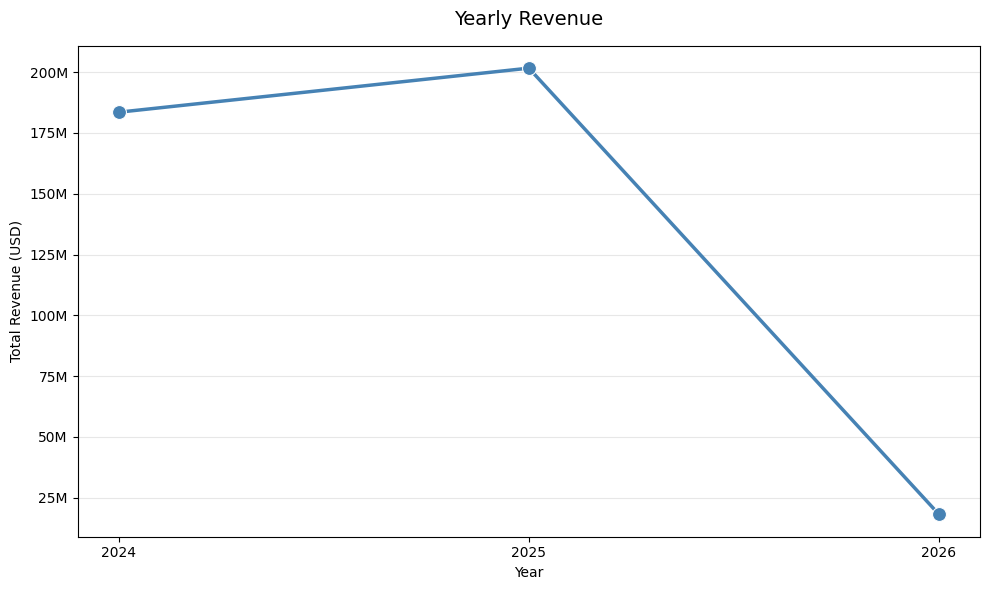

In [117]:
yearly_revenue = (
    sales_df.groupby('order_year')['net_revenue_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=yearly_revenue,
    x='order_year',
    y='net_revenue_usd',
    marker='o',
    markersize=10,
    linewidth=2.5,
    color='steelblue',
)

plt.title('Yearly Revenue', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Total Revenue (USD)')
plt.xticks(yearly_revenue['order_year'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 1.2 Revenue by Month

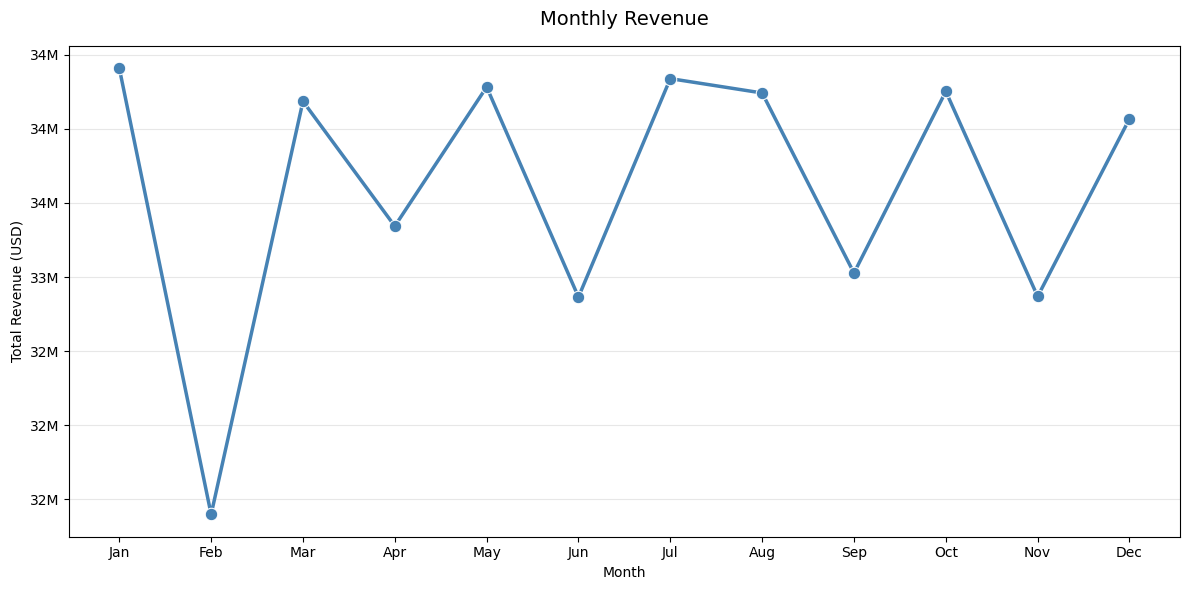

In [118]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_map = {i+1: m for i, m in enumerate(month_order)}

monthly_revenue = (
    sales_df.assign(
        order_month_name=sales_df['order_month'].map(month_map)
    )
    .groupby('order_month_name')['net_revenue_usd']
    .sum()
    .reindex(month_order)
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=monthly_revenue,
    x='order_month_name',
    y='net_revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue'
)

plt.title('Monthly Revenue', fontsize=14, pad=15)
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 1.3 Revenue by Day of Week

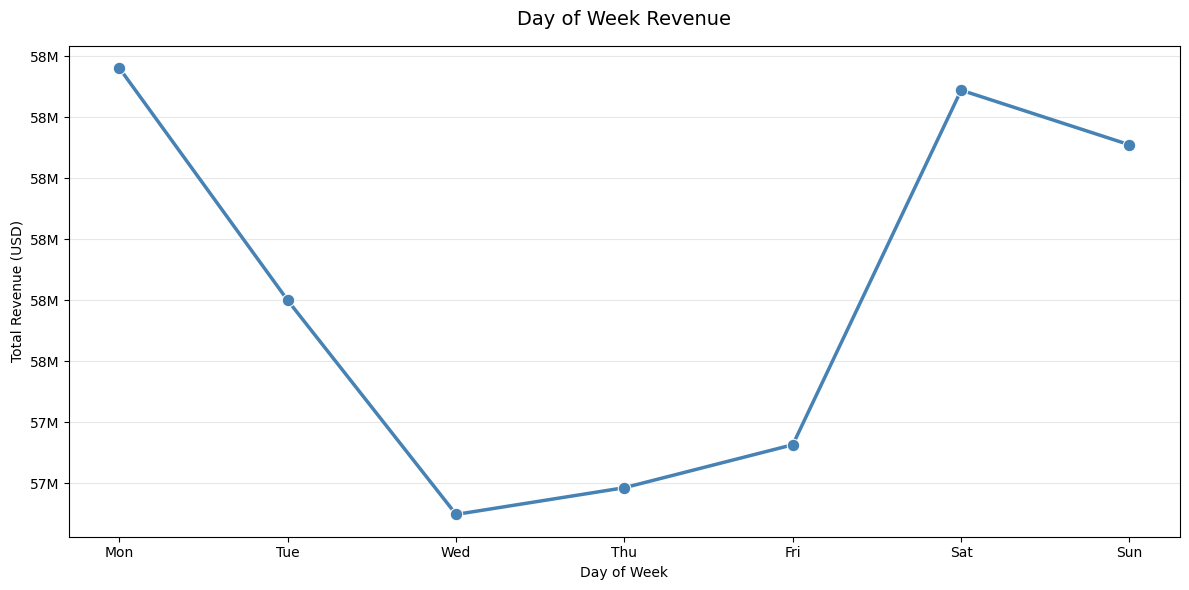

In [119]:
day_of_week_revenue = (
    sales_df.groupby('order_day_of_week')['net_revenue_usd']
    .sum()
    .reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=day_of_week_revenue,
    x='order_day_of_week',
    y='net_revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue',
)

plt.title('Day of Week Revenue', fontsize=14, pad=15)
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 1.4 Revenue by Part of Day

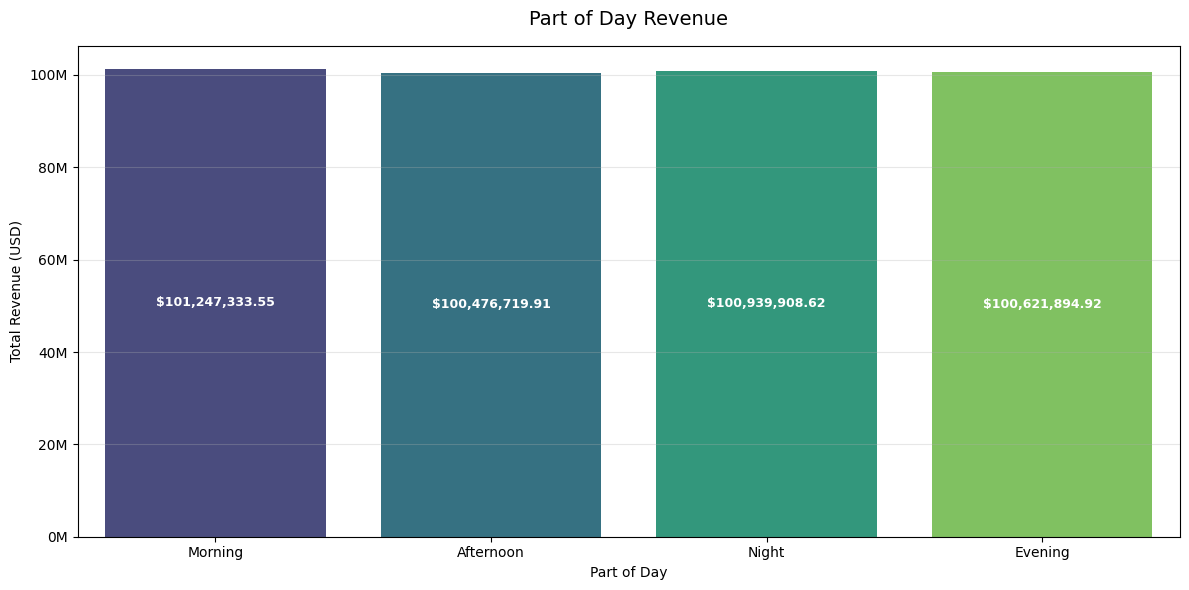

In [120]:

part_day_revenue = (
    sales_df.groupby('part_day')['net_revenue_usd']
    .sum()
    .reindex(['Morning', 'Afternoon', 'Night', 'Evening'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=part_day_revenue,
    x='part_day',
    y='net_revenue_usd',
    palette='viridis',
    hue='part_day',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Part of Day Revenue', fontsize=14, pad=15)
plt.xlabel('Part of Day')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 1.5 Revenue: Weekdays vs Weekends

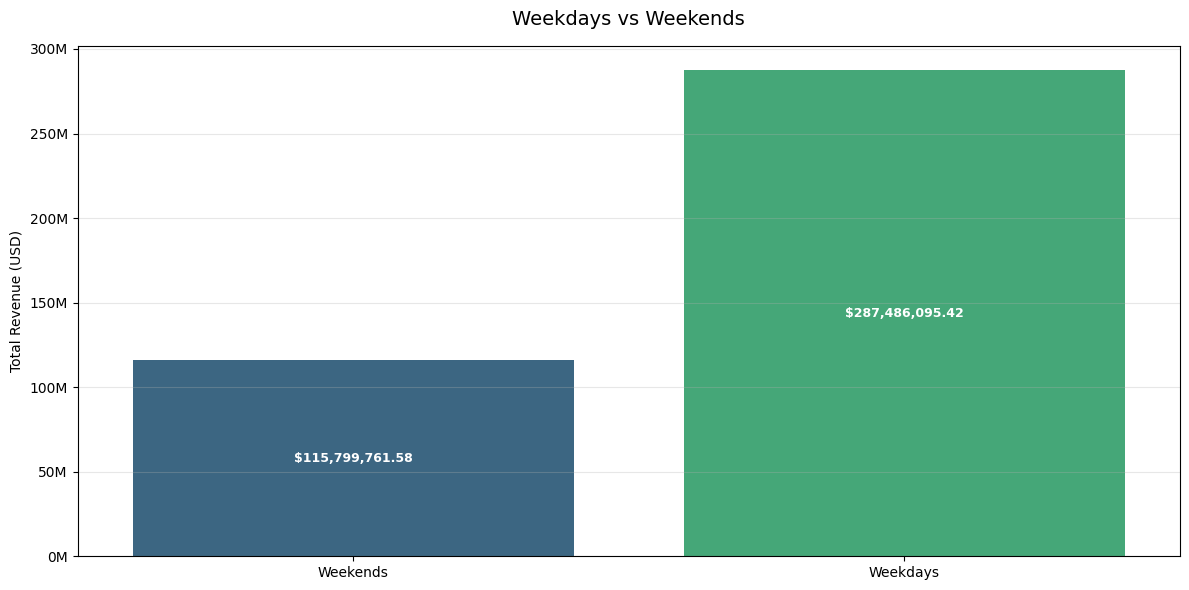

In [121]:
is_weekend_revenue = (
    sales_df.groupby('is_weekend')['net_revenue_usd']
    .sum()
    .reindex(['Yes', 'No'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=is_weekend_revenue,
    x='is_weekend',
    y='net_revenue_usd',
    palette='viridis',
    hue='is_weekend',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Weekdays vs Weekends', fontsize=14, pad=15)
plt.xlabel('')
plt.xticks([0, 1], ['Weekends', 'Weekdays'])
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Product Sales Performance

### 2.1 Revenue by Category

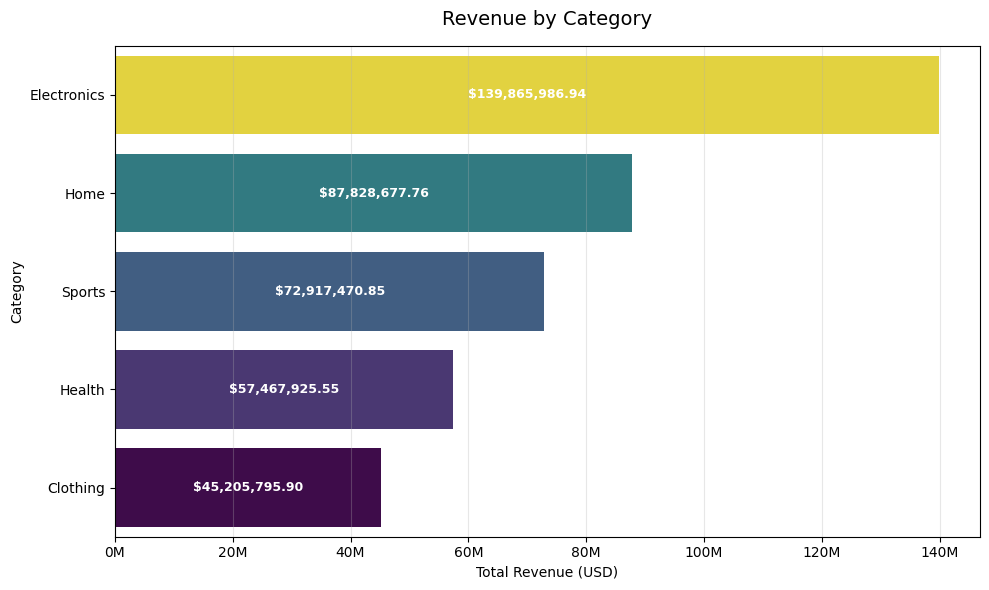

In [122]:

category_revenue = (
    sales_df.groupby('category')['net_revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=category_revenue,
    x='net_revenue_usd',
    y='category',
    palette='viridis',
    orient='h',
    hue='net_revenue_usd',
    legend=False
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Revenue by Category', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Category')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 Top 10 Revenue Sub-Categories

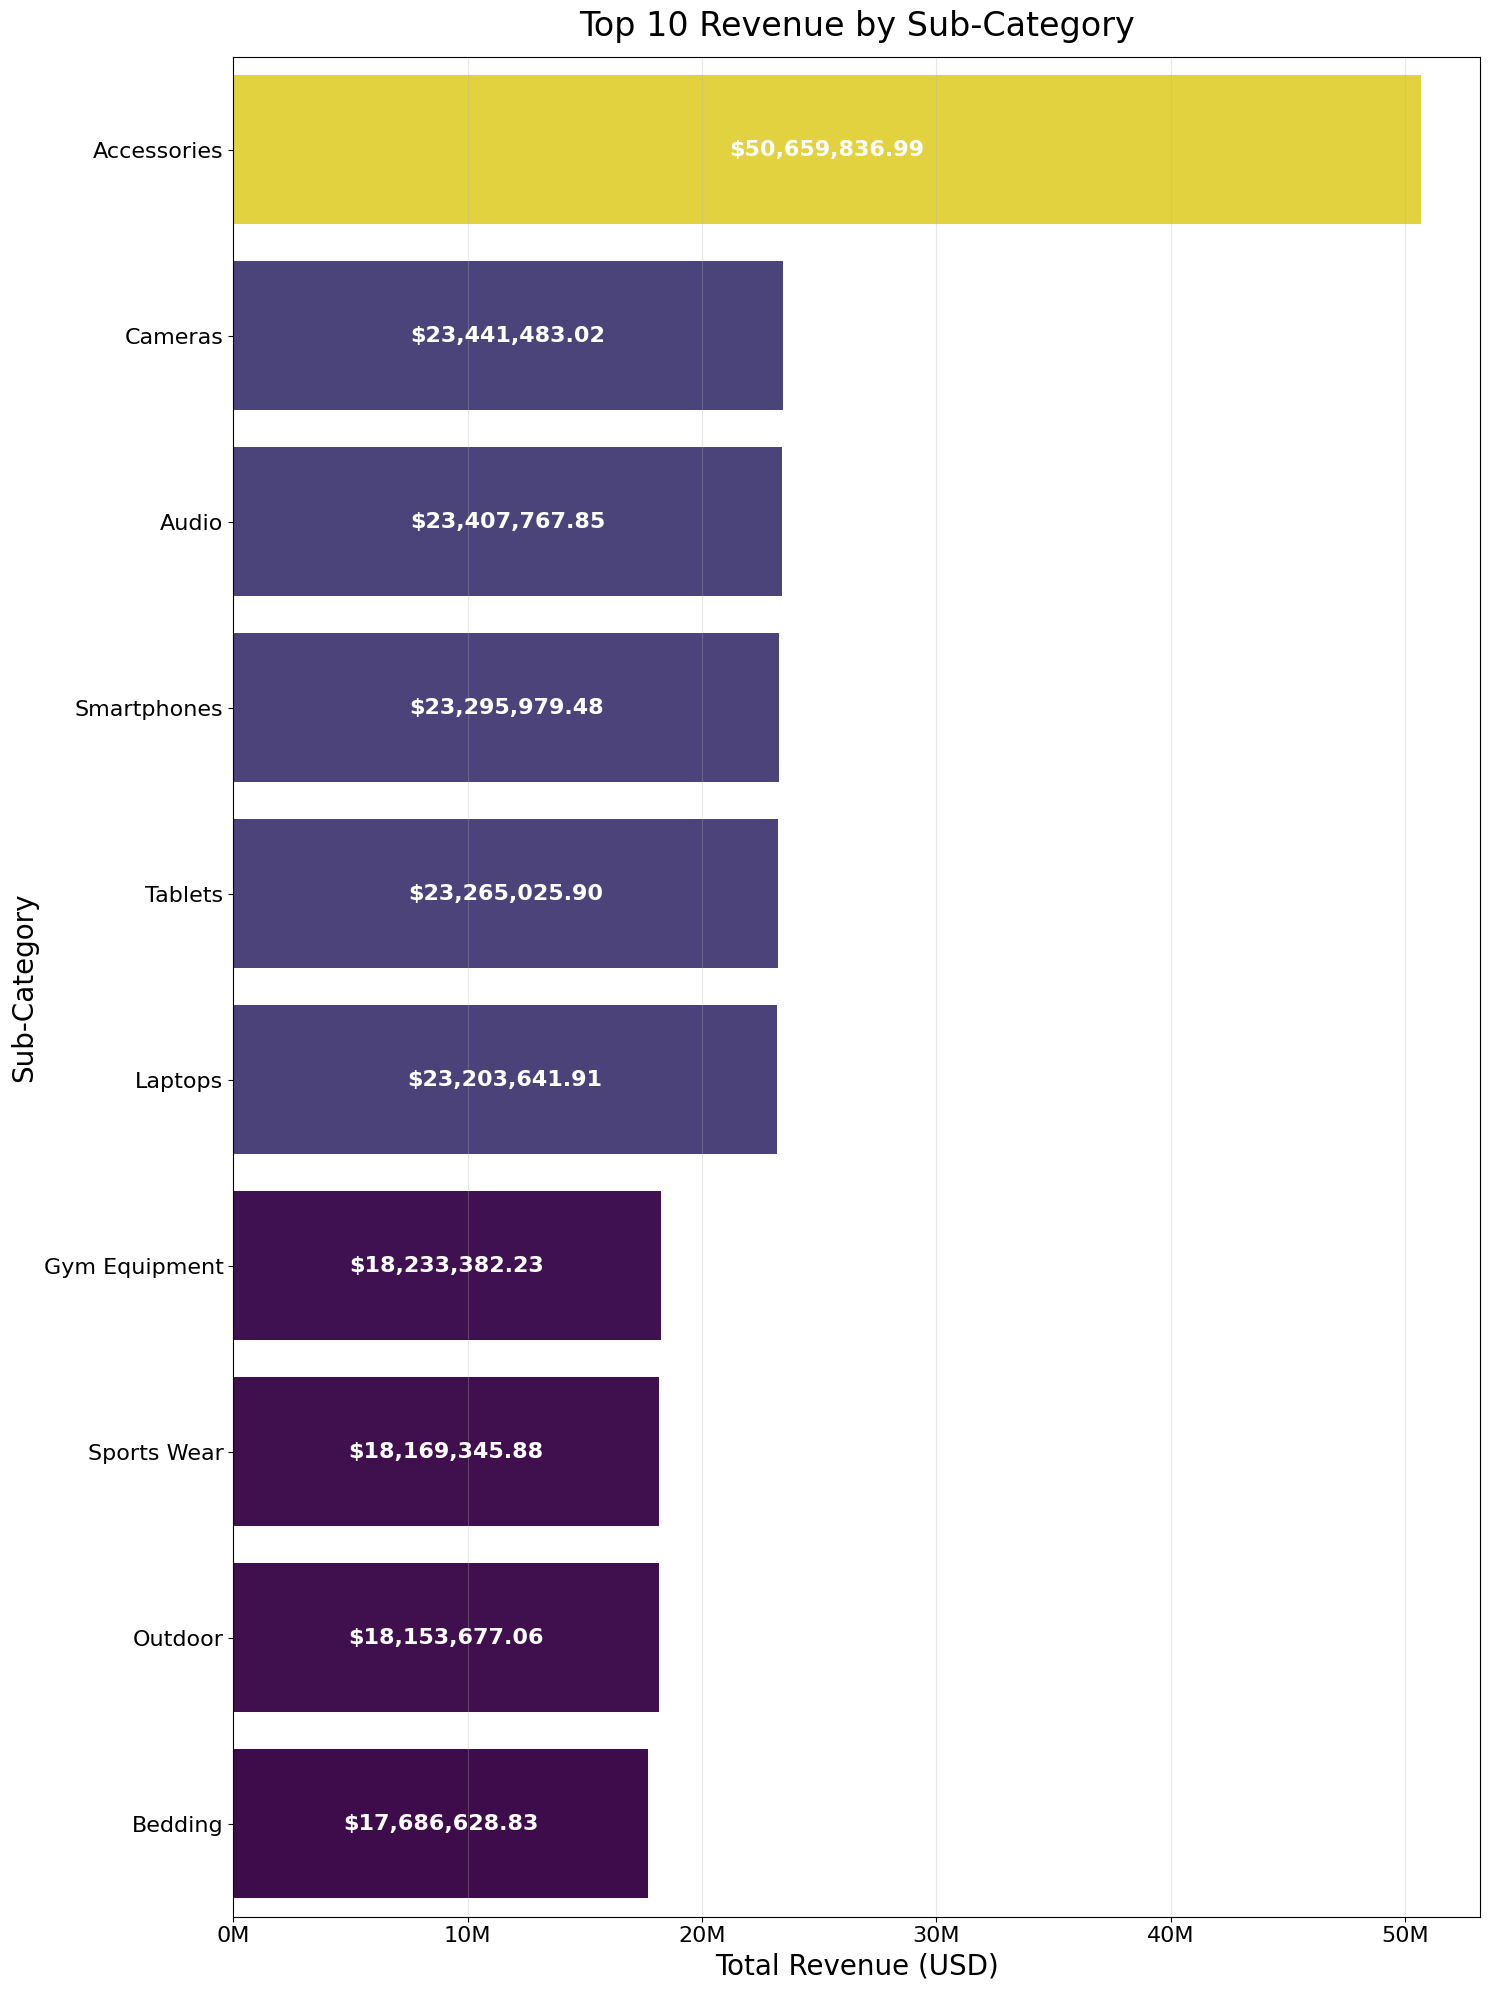

In [123]:
subcategory_revenue = (
    sales_df.groupby('sub_category')['net_revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(15, 20))

ax = sns.barplot(
    data=subcategory_revenue,
    x='net_revenue_usd',
    y='sub_category',
    palette='viridis',
    orient='h',
    hue='net_revenue_usd',
    legend=False
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=16,
        fontweight='bold'
    )
    

plt.title('Top 10 Revenue by Sub-Category', fontsize=24, pad=15)
plt.xlabel('Total Revenue (USD)', fontsize=20)
plt.ylabel('Sub-Category', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 2.3 Average Unit Price by Category and Price Tier

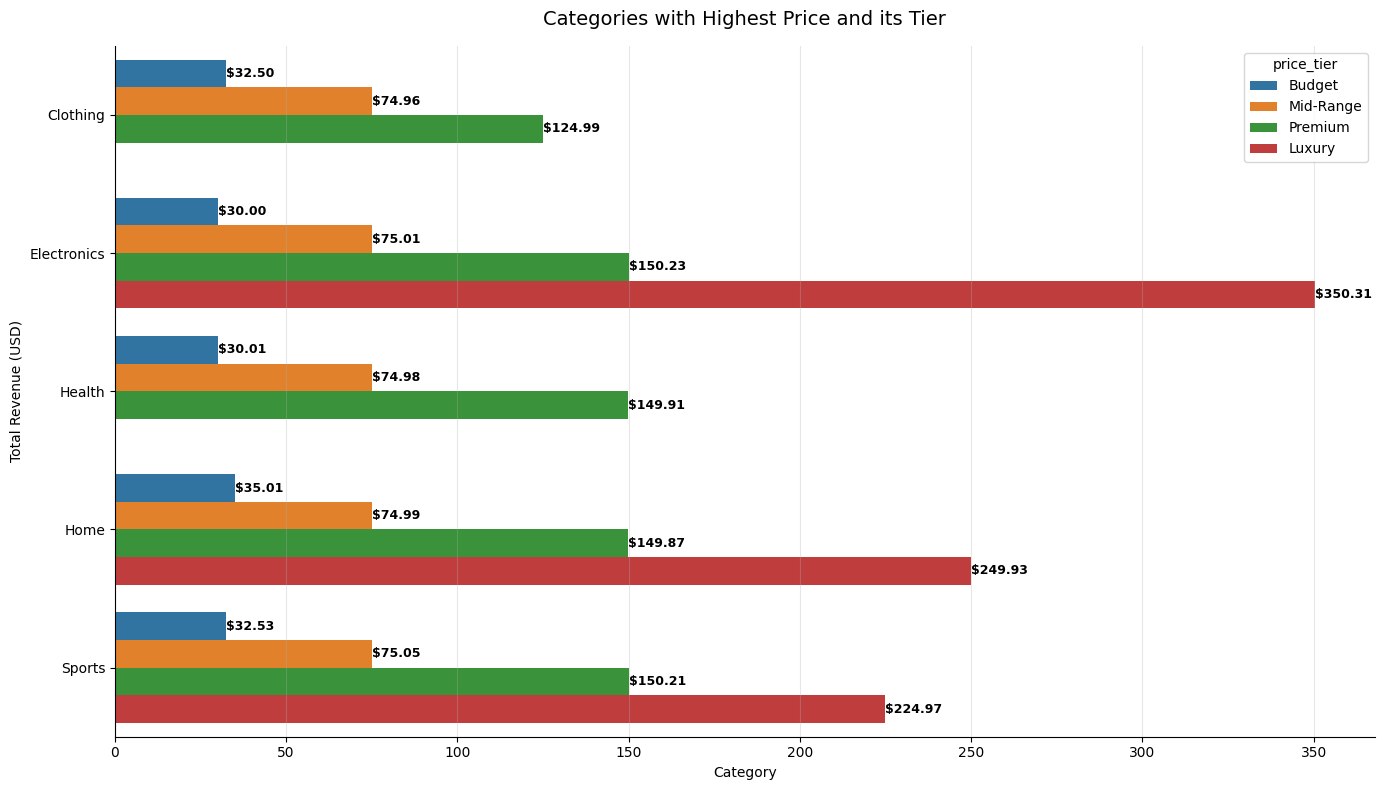

In [142]:
price_category = (
    sales_df
    .groupby(['category', 'price_tier'])['unit_price_usd']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=price_category,
    x='unit_price_usd',
    y='category',
    hue='price_tier',
    palette='tab10',
    orient='h'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Categories with Highest Price and its Tier', fontsize=14, pad=15)
plt.xlabel('Category')
plt.ylabel('Total Revenue (USD)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 2.4 Total Quantity Sold by Category

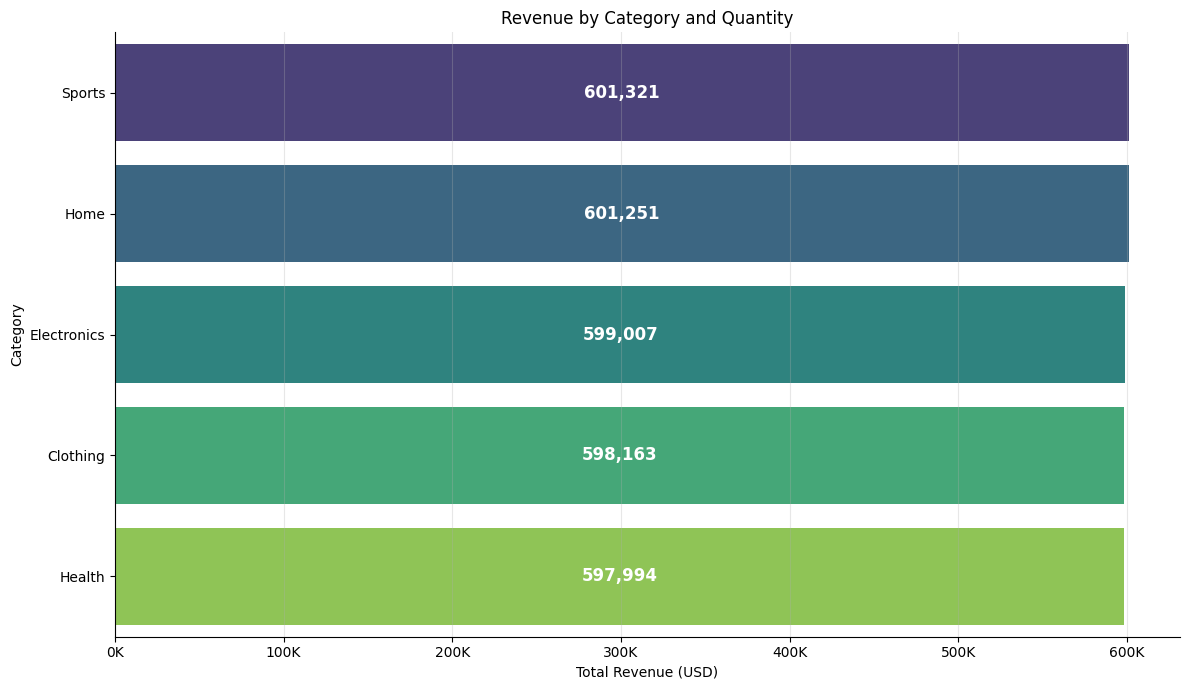

In [146]:
quantity_category = (
    sales_df
    .groupby('category')['quantity']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=quantity_category,
    x='quantity',
    y='category',
    palette='viridis',
    hue='category',
    legend=False,
    orient='h',
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.0f}' for v in container.datavalues],
        label_type='center',
        color='white',
        fontsize=12,
        fontweight='bold'
    )

plt.title('Revenue by Category and Quantity')
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Category')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Geographic Sales Performance

### 3.1 Revenue by Country

C:\Users\User\AppData\Local\Temp\ipykernel_6032\2291804543.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


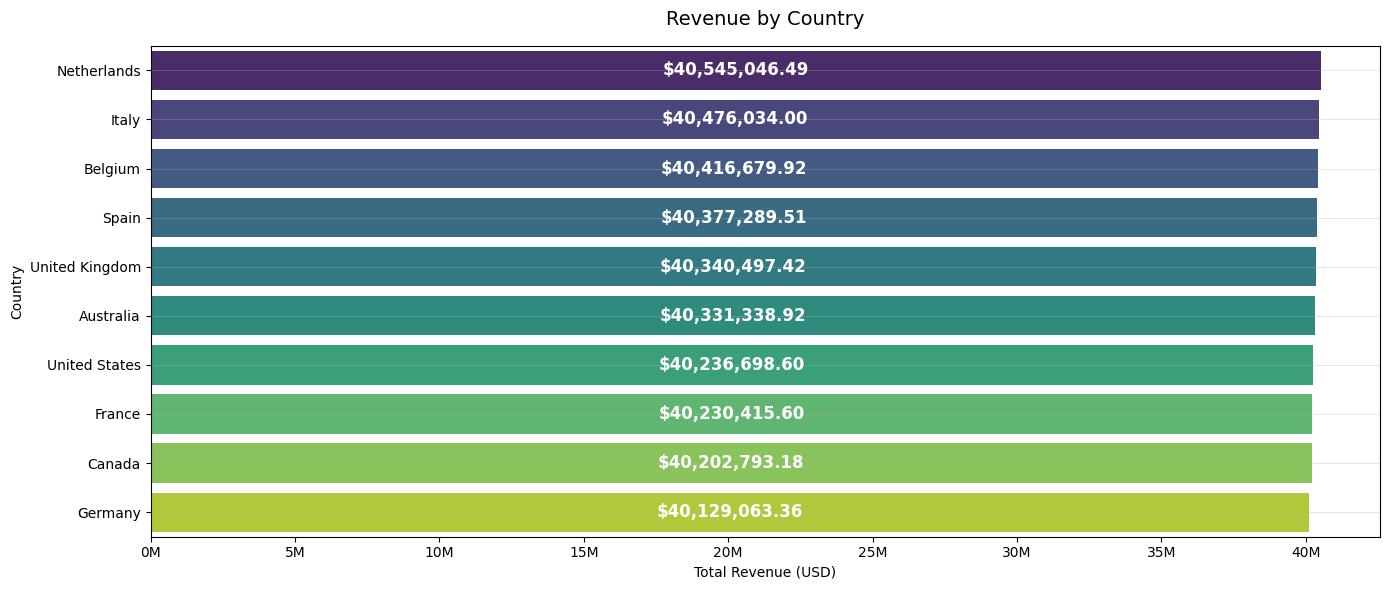

In [126]:
country_revenue = (
    sales_df.groupby('country')['net_revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=country_revenue,
    x='net_revenue_usd',
    y='country',
    orient='h',
    palette='viridis'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=12,
        fontweight='bold',
    )

plt.title('Revenue by Country', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Country')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Revenue by Country Across Years

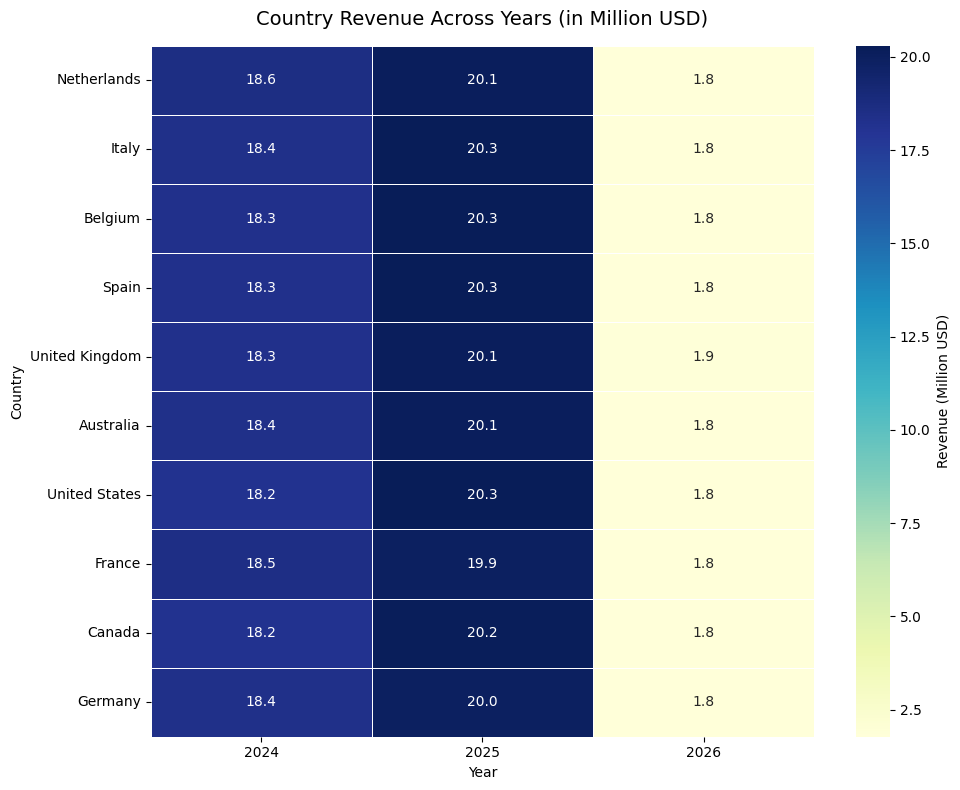

In [127]:
# Prepare data
country_yearly = (
    sales_df.groupby(['country', 'order_year'])['net_revenue_usd']
    .sum()
    .unstack(fill_value=0)          # years become columns
)

# Optional: sort by total revenue
country_yearly = country_yearly.loc[
    country_yearly.sum(axis=1).sort_values(ascending=False).index
]

plt.figure(figsize=(10, 8))
sns.heatmap(
    country_yearly / 1e6,           # show in millions
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Revenue (Million USD)'}
)

plt.title('Country Revenue Across Years (in Million USD)', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

## 4. Order Value Analysis

### 4.1 Revenue by Order Value Segment

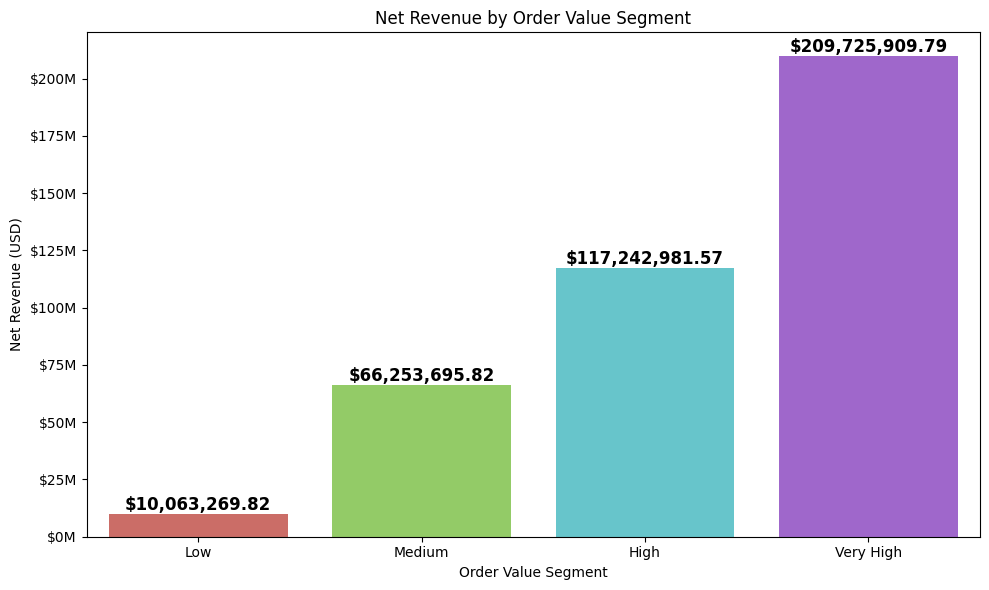

In [128]:
order_value_revenue = (
    sales_df
    .groupby('order_value_segment')['net_revenue_usd']
    .sum()
    .reset_index()
)

order_value_revenue['order_value_segment'] = pd.Categorical(
    order_value_revenue['order_value_segment'],
    categories=['Low', 'Medium', 'High', 'Very High'],
    ordered=True
)

order_value_revenue = order_value_revenue.sort_values('order_value_segment')

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=order_value_revenue,
    x='order_value_segment',
    y='net_revenue_usd',
    palette=sns.color_palette('hls',4),
    hue='order_value_segment',
    legend=False
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=12,
        fontweight='bold'
    )

plt.title('Net Revenue by Order Value Segment')
plt.xlabel('Order Value Segment')
plt.ylabel('Net Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

### 4.2 Order Value Segment Across Categories

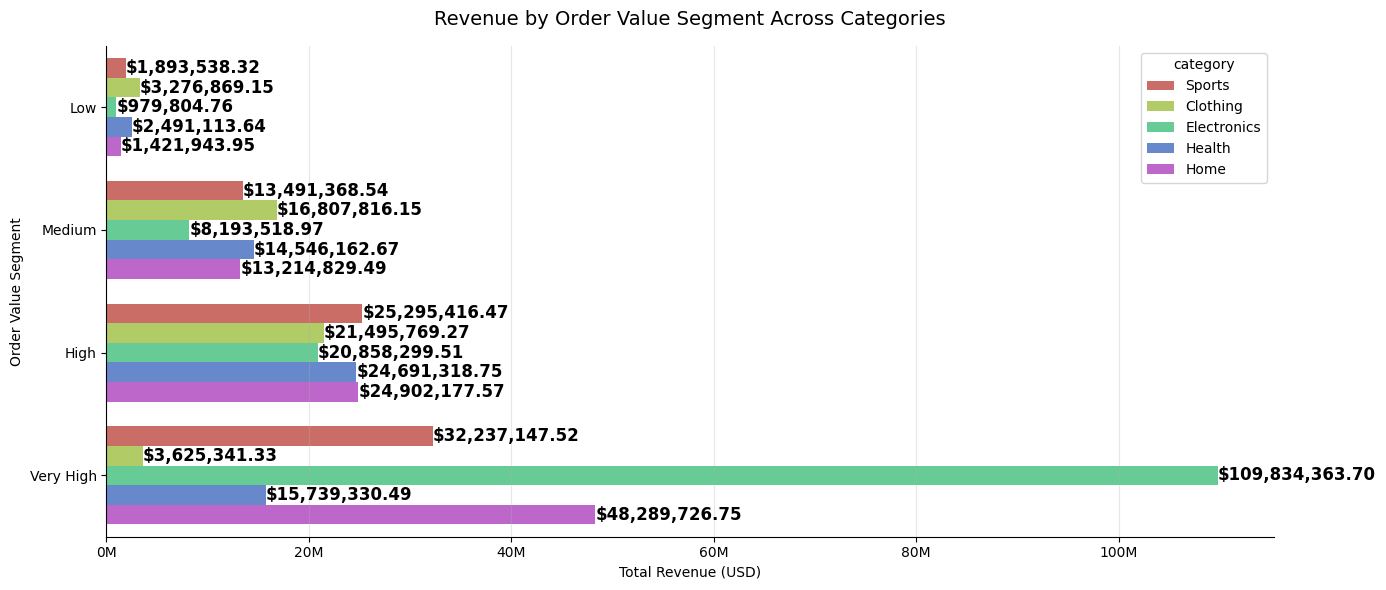

In [ ]:
order_value_segment_revenue = (
    sales_df
    .groupby(['order_value_segment', 'category'])['net_revenue_usd']
    .sum()
    .reset_index()
)

order_value_segment_revenue['order_value_segment'] = pd.Categorical(
    order_value_segment_revenue['order_value_segment'],
    categories=['Low', 'Medium', 'High', 'Very High'],
    ordered=True
)

order_value_segment_revenue = order_value_segment_revenue.sort_values('order_value_segment')

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=order_value_segment_revenue,
    x='net_revenue_usd',
    y='order_value_segment',
    hue='category',
    palette='viridis',
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Revenue by Order Value Segment Across Categories', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel("Order Value Segment")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Sales Analysis by Customer Attributes

### 5.1 Revenue Contribution by Customer Segment (%)

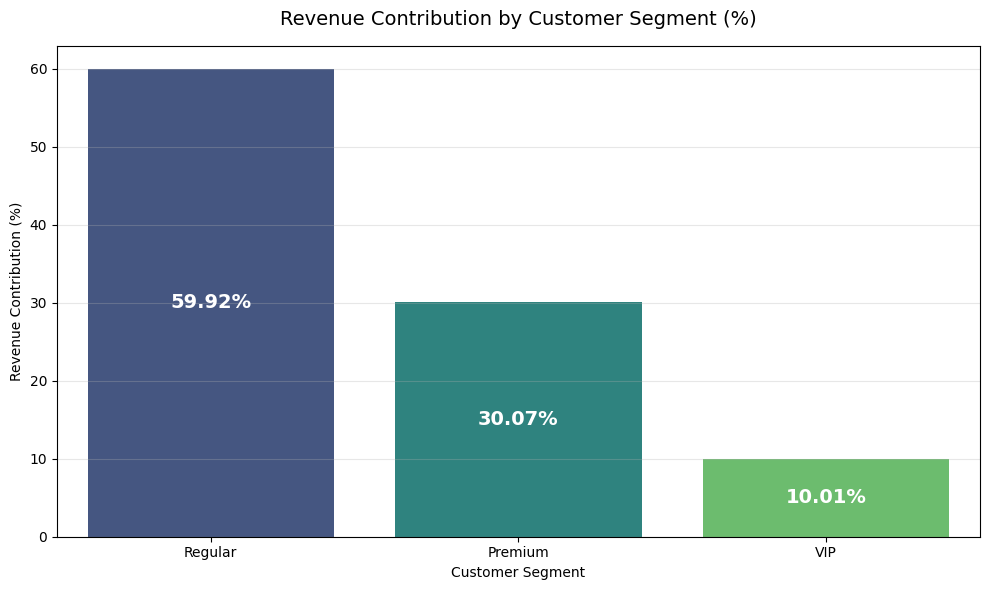

In [130]:
customer_segment_revenue = sales_df.groupby('customer_segment')['net_revenue_usd'].sum().reset_index().sort_values('net_revenue_usd', ascending=False).head(15)

total_revenue = customer_segment_revenue['net_revenue_usd'].sum()
customer_segment_revenue['revenue_pct'] = (customer_segment_revenue['net_revenue_usd'] / total_revenue) * 100

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=customer_segment_revenue,
    x='customer_segment',
    y='revenue_pct',
    hue='customer_segment',
    legend=False,
    palette='viridis'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.2f}%' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=14,
        fontweight='bold'
    )
    
plt.title('Revenue Contribution by Customer Segment (%)', fontsize=14, pad=15)
plt.xlabel('Customer Segment')
plt.ylabel("Revenue Contribution (%)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 Revenue Contribution by Age Group (%)

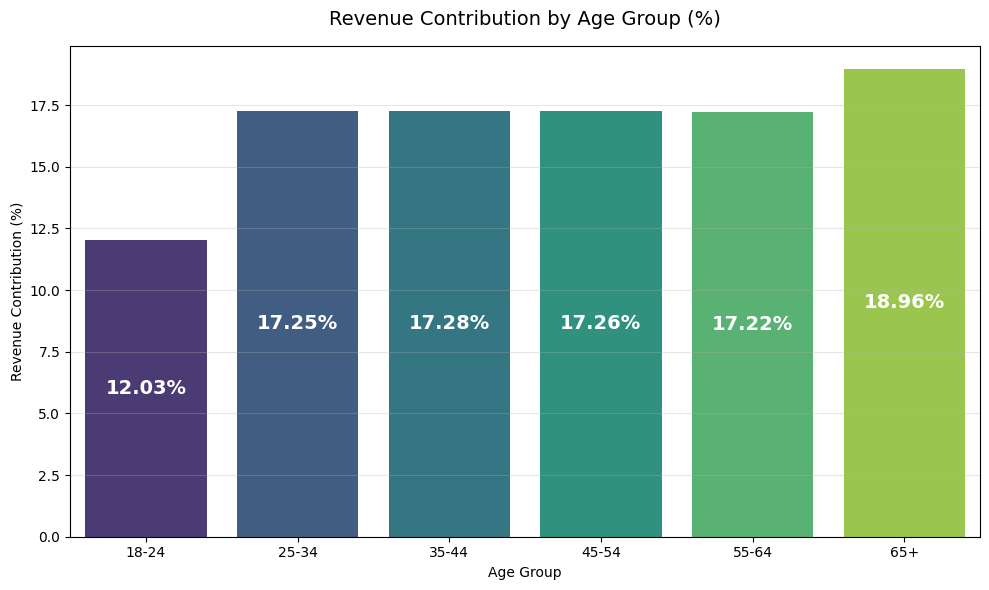

In [131]:
age_group_revenue = (
    sales_df
    .groupby('age_group')['net_revenue_usd']
    .sum()
    .reindex(['18-24', '25-34', '35-44', '45-54', '55-64', '65+'])
    .reset_index()
    .head(15)
)

total_revenue = age_group_revenue['net_revenue_usd'].sum()
age_group_revenue['revenue_pct'] = (age_group_revenue['net_revenue_usd'] / total_revenue) * 100

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=age_group_revenue,
    x='age_group',
    y='revenue_pct',
    hue='age_group',
    legend=False,
    palette='viridis'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.2f}%' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=14,
        fontweight='bold'
    )
    
plt.title('Revenue Contribution by Age Group (%)', fontsize=14, pad=15)
plt.xlabel('Age Group')
plt.ylabel("Revenue Contribution (%)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Revenue Contribution by Gender (%)

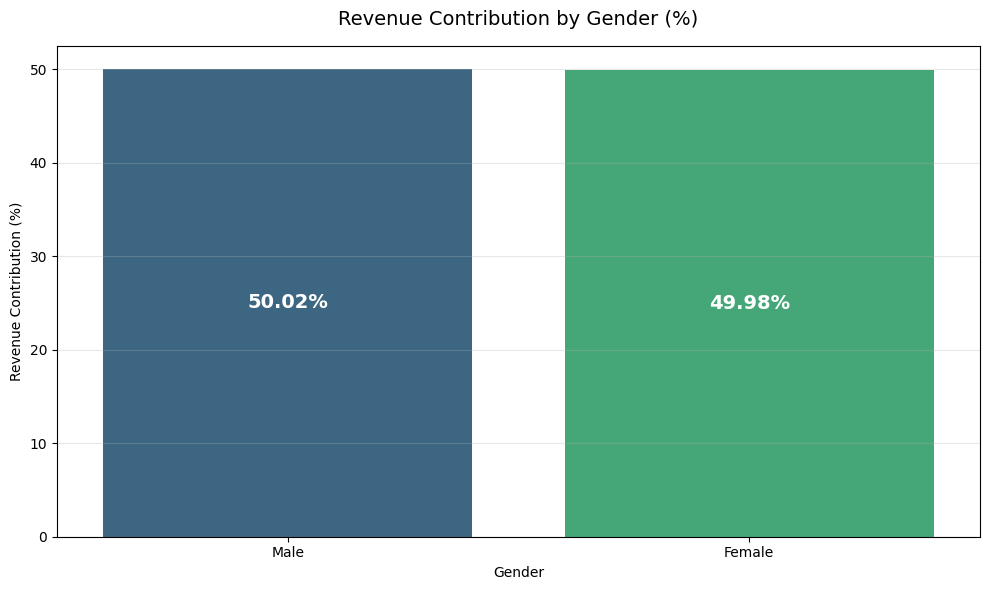

In [132]:
gender_revenue = (
    sales_df
    .groupby('gender')['net_revenue_usd']
    .sum()
    .reindex(['Male', 'Female'])
    .reset_index()
    .head(15)
)

total_revenue = gender_revenue['net_revenue_usd'].sum()
gender_revenue['revenue_pct'] = (gender_revenue['net_revenue_usd'] / total_revenue) * 100

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=gender_revenue,
    x='gender',
    y='revenue_pct',
    hue='gender',
    legend=False,
    palette='viridis'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.2f}%' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=14,
        fontweight='bold'
    )
    
plt.title('Revenue Contribution by Gender (%)', fontsize=14, pad=15)
plt.xlabel('Gender')
plt.ylabel("Revenue Contribution (%)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 Average Order Value by Customer Segment

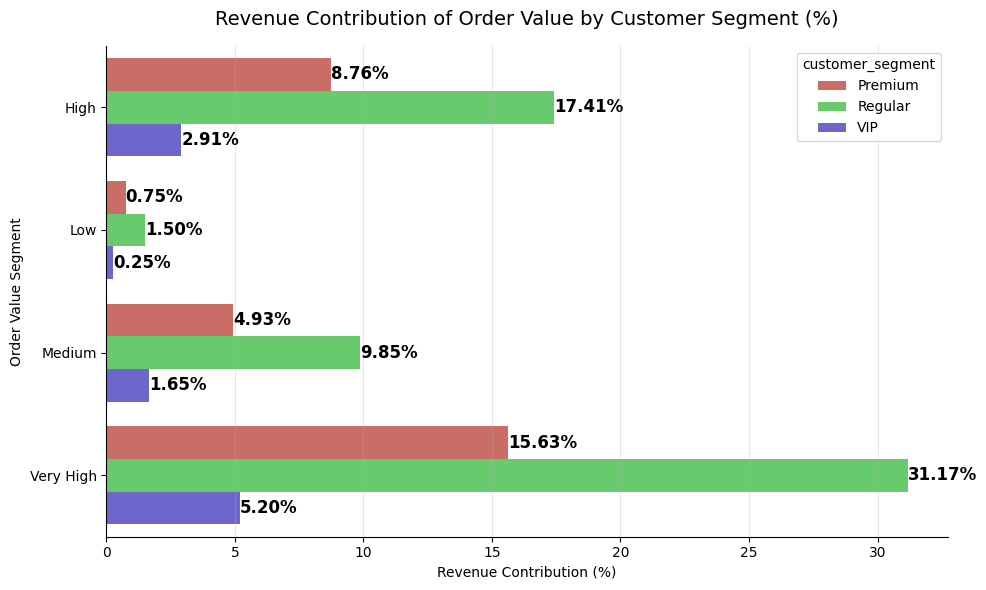

In [133]:
order_value_by_customer_segment = (
    sales_df
    .groupby(['customer_segment', 'order_value_segment'])['net_revenue_usd']
    .sum()
    .reset_index()
)

total_revenue = order_value_by_customer_segment['net_revenue_usd'].sum()
order_value_by_customer_segment['revenue_pct'] = (order_value_by_customer_segment['net_revenue_usd'] / total_revenue) * 100

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=order_value_by_customer_segment,
    x='revenue_pct',
    y='order_value_segment',
    hue='customer_segment',
    palette=sns.color_palette('hls', 3),
    orient='h'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:,.2f}%' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Revenue Contribution of Order Value by Customer Segment (%)', fontsize=14, pad=15)
plt.xlabel('Revenue Contribution (%)')
plt.ylabel("Order Value Segment")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Profitability Analysis

### 6.1 Profit by Category Across Year

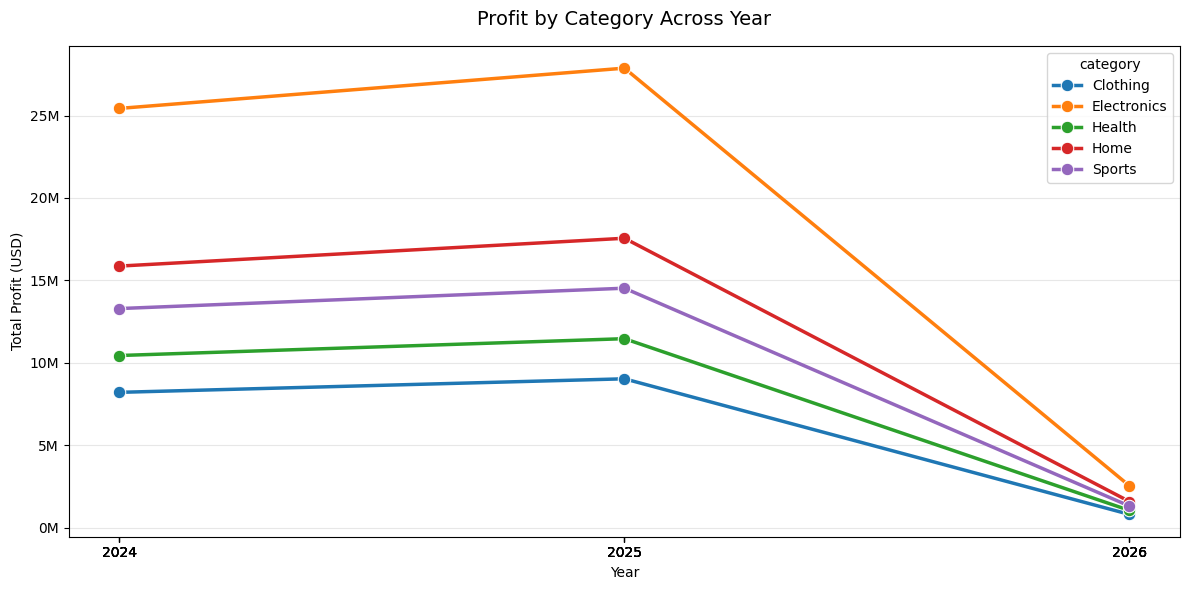

In [134]:
category_profit = (
    sales_df
    .groupby(['order_year', 'category'])['profit_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=category_profit,
    x='order_year',
    y='profit_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    palette='tab10',
    hue='category'
)

plt.title('Profit by Category Across Year', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Total Profit (USD)')
plt.xticks(category_profit['order_year'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



### 6.2 Profit Margin by Category

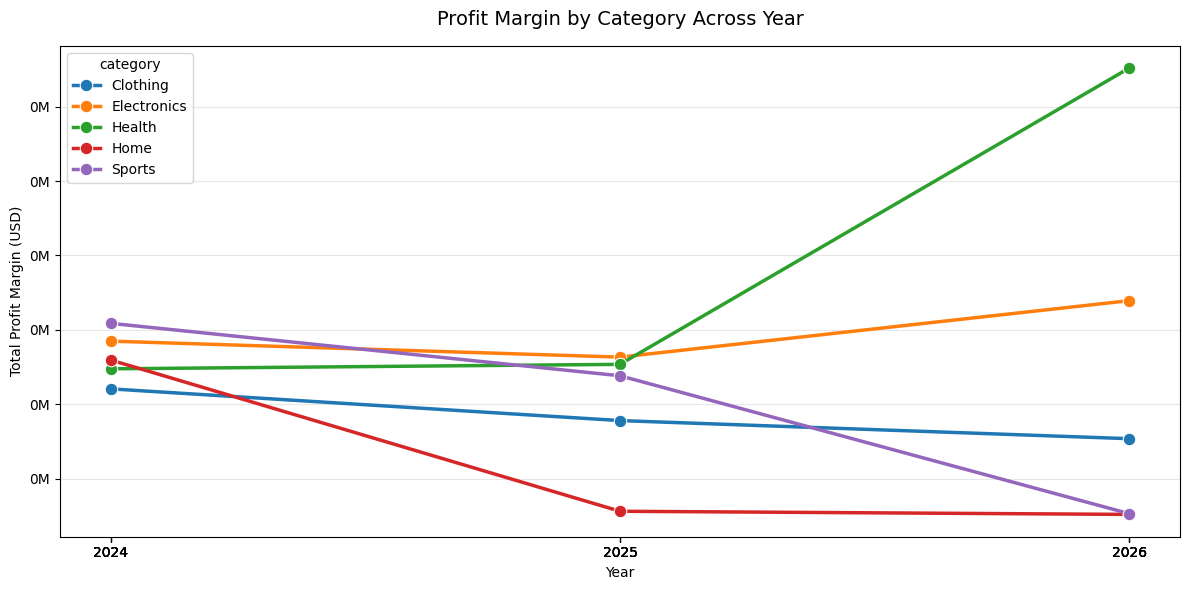

In [135]:
category_profit_margin = (
    sales_df
    .groupby(['order_year', 'category'])['profit_margin_percent']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=category_profit_margin,
    x='order_year',
    y='profit_margin_percent',
    marker='o',
    markersize=9,
    linewidth=2.5,
    palette='tab10',
    hue='category'
)

plt.title('Profit Margin by Category Across Year', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Total Profit Margin (USD)')
plt.xticks(category_profit_margin['order_year'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



### 6.3 Profit by Country

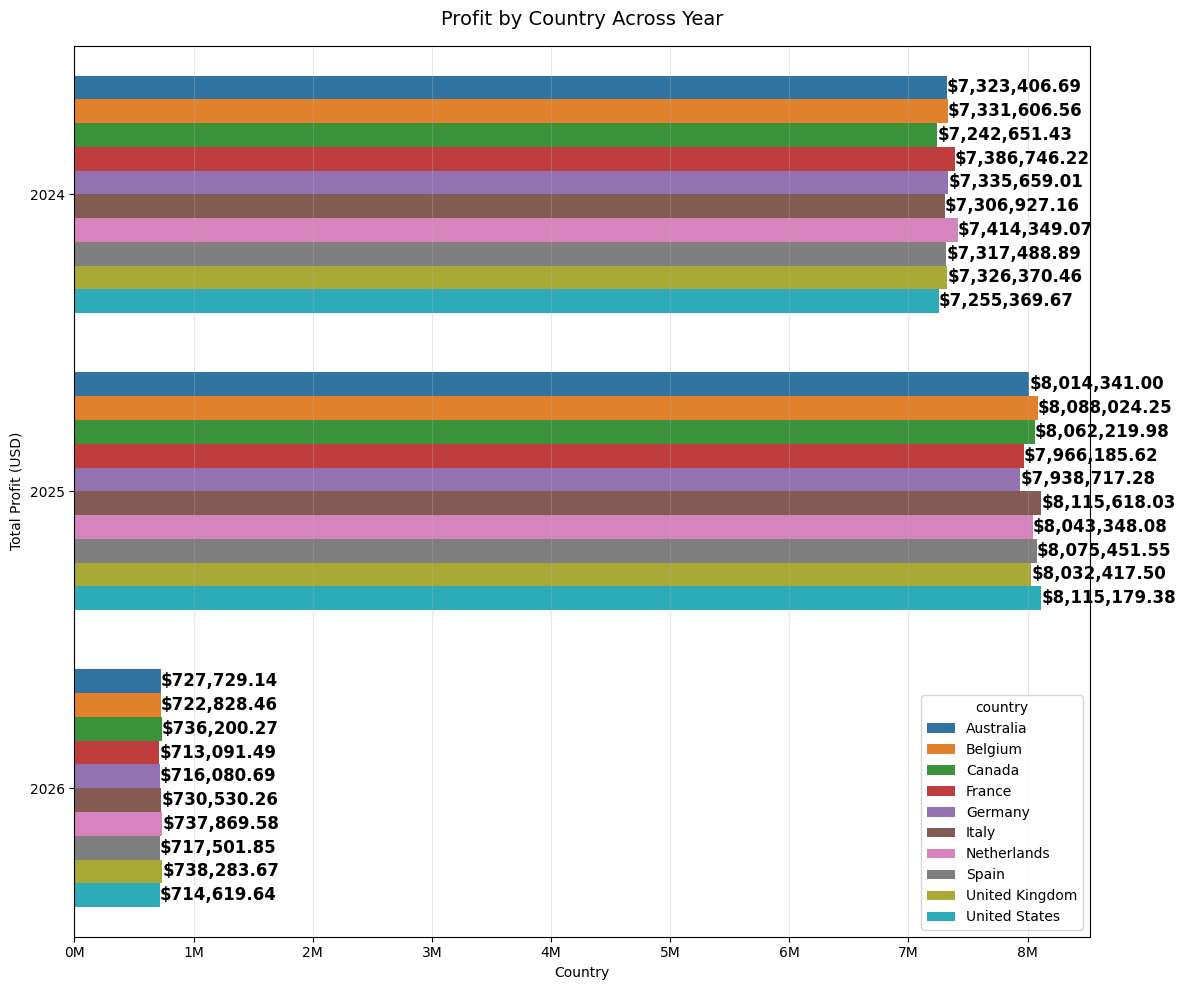

In [136]:
profit_country = (
    sales_df
    .groupby(['order_year', 'country'])['profit_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 10))

ax = sns.barplot(
    data=profit_country,
    x='profit_usd',
    y='order_year',
    palette='tab10',
    hue='country',
    orient='h'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=12,
        fontweight='bold'
    )

plt.title('Profit by Country Across Year', fontsize=14, pad=15)
plt.xlabel('Country')
plt.ylabel('Total Profit (USD)')
# plt.xticks(profit_country['order_year'])
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()



### 6.4 Revenue vs Profit by Category

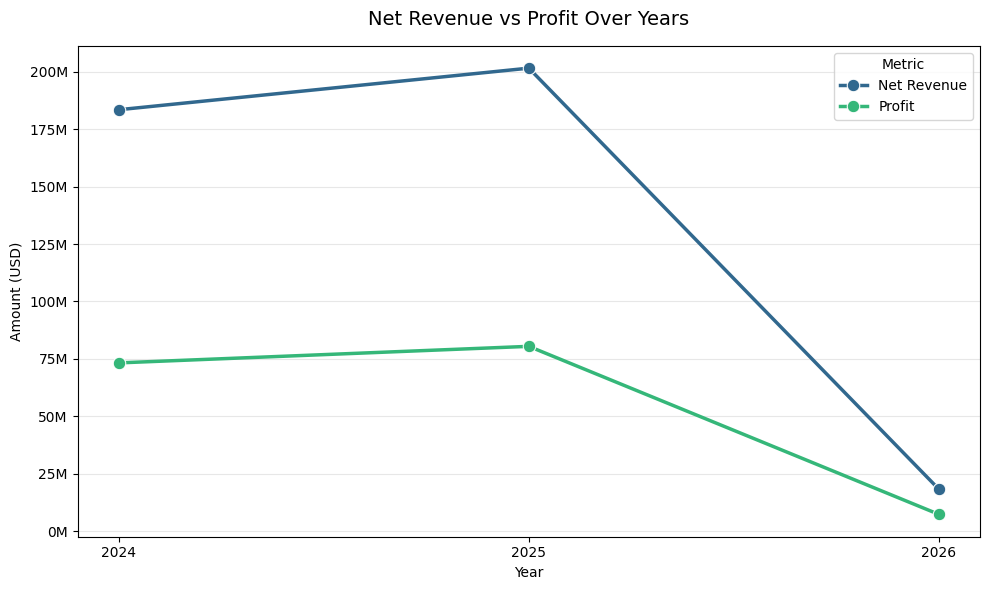

In [137]:
profit_vs_revenue = (
    sales_df
    .groupby('order_year')[['net_revenue_usd', 'profit_usd']]
    .sum()
    .reset_index()
)

profit_vs_revenue = profit_vs_revenue.rename(columns={
    'net_revenue_usd': 'Net Revenue',
    'profit_usd': 'Profit'
})

profit_vs_revenue_melted = profit_vs_revenue.melt(
    id_vars='order_year',
    value_vars=['Net Revenue', 'Profit'],
    var_name='metric',
    value_name='amount'
)

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=profit_vs_revenue_melted,
    x='order_year',
    y='amount',
    hue='metric',
    marker='o',
    markersize=9,
    linewidth=2.5,
    palette='viridis'
)

plt.title('Net Revenue vs Profit Over Years', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Amount (USD)')
plt.xticks(profit_vs_revenue['order_year'])
plt.legend(title='Metric')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Discount Analysis

### 7.1 Gross vs Net Revenue

### 7.2 Discount Impact by Year

### 7.3 Discounted vs Non-Discounted Transactions

### 7.4 Discounted vs Non-Discounted Profitability

## 1.5 Customers

In [138]:
# 1.5.1 Top 15 Customers with Highest Revenue and their Customer Segment


In [139]:
# 1.5.2 Customer Segment Revenue



## 1.6 Gross Revenue (Without discount) vs Revenue (With discount applied)

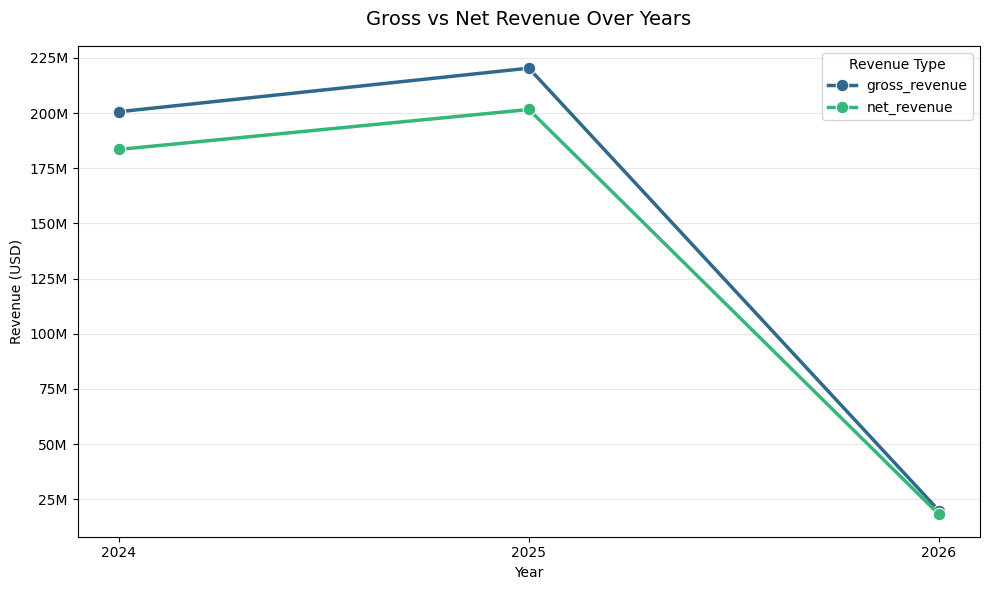

In [140]:
# 1.6.1 Gross Revenue vs Net Revenue (Overall Discount Impact)

yearly = sales_df.groupby('order_year').agg(
    gross_revenue=('gross_revenue_usd', 'sum'),
    net_revenue=('net_revenue_usd', 'sum')
).reset_index()

# Reshape for seaborn
yearly_melted = yearly.melt(
    id_vars='order_year',
    value_vars=['gross_revenue', 'net_revenue'],
    var_name='revenue_type',
    value_name='revenue'
)

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=yearly_melted,
    x='order_year',
    y='revenue',
    hue='revenue_type',
    marker='o',
    markersize=9,
    linewidth=2.5,
    palette='viridis'
)

plt.title('Gross vs Net Revenue Over Years', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Revenue (USD)')
plt.xticks(yearly['order_year'])
plt.legend(title='Revenue Type')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

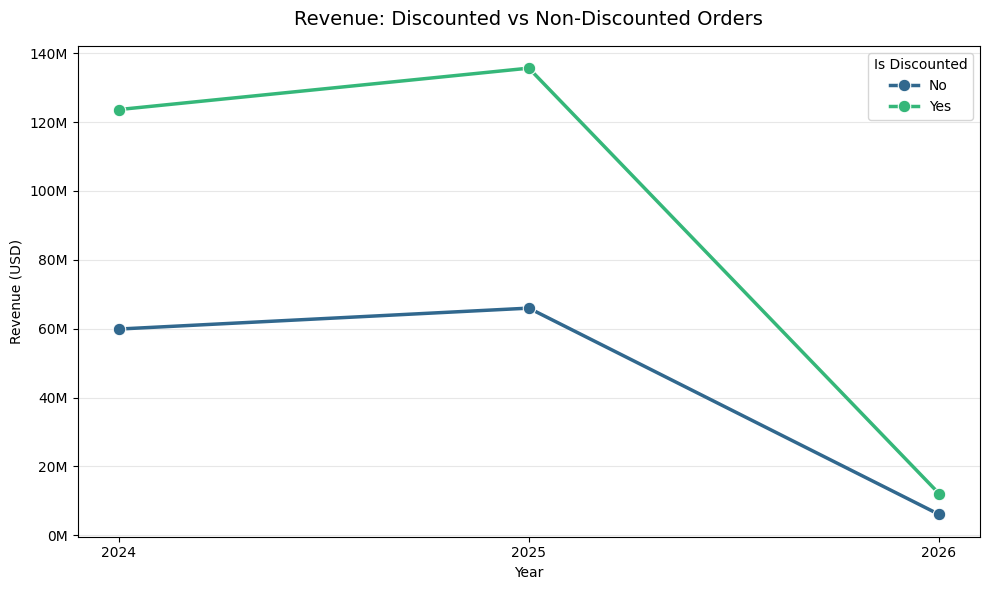

In [141]:
# 1.6.2 Discounted vs Non-Discounted Orders Revenue

discount_rev = (
    sales_df.groupby(['order_year', 'is_discounted'])['net_revenue_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=discount_rev,
    x='order_year',
    y='net_revenue_usd',
    hue='is_discounted',
    marker='o',
    markersize=9,
    linewidth=2.5,
    palette='viridis'
)

plt.title('Revenue: Discounted vs Non-Discounted Orders', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Revenue (USD)')
plt.xticks([2024, 2025, 2026])
plt.legend(title='Is Discounted')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()